In [2]:
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

JRA_DIR = Path("/leonardo_scratch/fast/ICT26_ESP/ntilinin/INPUT/OMIP")
SPEEDY_DIR = Path("/leonardo_scratch/fast/ICT26_ESP/ntilinin/SPEEDY_access/access_forcing")

# 1990 only
U0_JRA_FILES = sorted(JRA_DIR.glob("uas_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-5-0_gr_1990*.nc"))
V0_JRA_FILES = sorted(JRA_DIR.glob("vas_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-5-0_gr_1990*.nc"))
MSLP_JRA_FILES = sorted(JRA_DIR.glob("psl_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-5-0_gr_1990*.nc"))

U0_SPEEDY_FILES = [SPEEDY_DIR / "uas_SPEEDY_1990.nc"]
V0_SPEEDY_FILES = [SPEEDY_DIR / "vas_SPEEDY_1990.nc"]
MSLP_SPEEDY_FILES = [SPEEDY_DIR / "psl_SPEEDY_1990.nc"]

# Open
U0_JRA = xr.open_mfdataset(U0_JRA_FILES, combine="by_coords", chunks={"time": 120},
                           data_vars="minimal", coords="minimal", compat="override")["uas"]
U0_SPEEDY = xr.open_mfdataset(U0_SPEEDY_FILES, combine="by_coords", chunks={"time": 120},
                              data_vars="minimal", coords="minimal", compat="override")["uas"]

V0_JRA = xr.open_mfdataset(V0_JRA_FILES, combine="by_coords", chunks={"time": 120},
                           data_vars="minimal", coords="minimal", compat="override")["vas"]
V0_SPEEDY = xr.open_mfdataset(V0_SPEEDY_FILES, combine="by_coords", chunks={"time": 120},
                              data_vars="minimal", coords="minimal", compat="override")["vas"]

MSLP_JRA = xr.open_mfdataset(MSLP_JRA_FILES, combine="by_coords", chunks={"time": 120},
                             data_vars="minimal", coords="minimal", compat="override")["psl"]
MSLP_SPEEDY = xr.open_mfdataset(MSLP_SPEEDY_FILES, combine="by_coords", chunks={"time": 120},
                                data_vars="minimal", coords="minimal", compat="override")["psl"]

In [ ]:
# JRA -> SPEEDY grid
U0_JRA_S = U0_JRA.interp(lat=U0_SPEEDY.lat, lon=U0_SPEEDY.lon)
V0_JRA_S = V0_JRA.interp(lat=V0_SPEEDY.lat, lon=V0_SPEEDY.lon)
del U0_JRA, V0_JRA

In [ ]:
WIND_SPEEDY = np.sqrt(U0_SPEEDY**2 + V0_SPEEDY**2).compute()

In [ ]:
WIND_JRA = np.sqrt(U0_JRA_S**2 + V0_JRA_S**2).compute()

In [ ]:
WIND_JRA_mean = WIND_JRA.mean("time", skipna=True).compute()

In [ ]:
WIND_SPEEDY_mean = WIND_SPEEDY.mean("time", skipna=True).compute()

In [ ]:
def normalize_lon(da):
    return da.assign_coords(lon=((da.lon + 180) % 360) - 180).sortby("lon")

WIND_JRA_mean = normalize_lon(WIND_JRA_mean)
WIND_SPEEDY_mean = normalize_lon(WIND_SPEEDY_mean)

WIND_diff=WIND_SPEEDY_mean-WIND_JRA_mean
# MSLP_JRA_mean = normalize_lon(MSLP_JRA_mean)
# MSLP_SPEEDY_mean = normalize_lon(MSLP_SPEEDY_mean)

In [ ]:
sns.set_theme(style="white")
plt.rcParams.update({"font.family": "Nimbus Sans"})

wind_cmap = plt.get_cmap("turbo")

diff_cmap = LinearSegmentedColormap.from_list(
    "WindBlueWhiteRed",
    ["#313695","#4575b4","#74add1","#abd9e9","#e0f3f8","#ffffff",
     "#fee090","#fdae61","#f46d43","#d73027","#a50026"], N=256
)

wind_levels = np.arange(0, 16.5, 0.5)
wind_ticks = np.arange(0, 17, 2)

diff_levels = np.arange(-5, 5.25, 0.25)
diff_norm = mcolors.TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5)
diff_ticks = np.arange(-5, 6, 1)

def make_cyclic(da):
    data, lon = add_cyclic_point(
        da.values, coord=da.lon.values, axis=da.get_axis_num("lon")
    )
    return data, lon

def setup_map(ax):
    ax.set_global()
    ax.coastlines(resolution="110m", linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)

fig = plt.figure(figsize=(14, 9), facecolor="white")
gs = fig.add_gridspec(2, 6, height_ratios=[1, 1.3], hspace=0.42, wspace=0.12)

ax1 = fig.add_subplot(gs[0, 0:3], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[0, 3:6], projection=ccrs.PlateCarree())
ax3 = fig.add_subplot(gs[1, 0:6], projection=ccrs.PlateCarree())

# JRA55
data, lon = make_cyclic(WIND_JRA_mean)
im1 = ax1.contourf(
    lon, WIND_JRA_mean.lat, data, levels=wind_levels,
    cmap=wind_cmap, transform=ccrs.PlateCarree(), extend="max"
)
setup_map(ax1)
ax1.set_title("Annual mean wind speed JRA55, 1990",
              fontsize=14, fontweight="bold", pad=10)

# SPEEDY
data, lon = make_cyclic(WIND_SPEEDY_mean)
im2 = ax2.contourf(
    lon, WIND_SPEEDY_mean.lat, data, levels=wind_levels,
    cmap=wind_cmap, transform=ccrs.PlateCarree(), extend="max"
)
setup_map(ax2)
ax2.set_title("Annual mean wind speed SPEEDY T30, 1990",
              fontsize=14, fontweight="bold", pad=10)

# Difference
data, lon = make_cyclic(WIND_diff)
im3 = ax3.contourf(
    lon, WIND_diff.lat, data, levels=diff_levels,
    norm=diff_norm, cmap=diff_cmap,
    transform=ccrs.PlateCarree(), extend="both"
)
setup_map(ax3)
ax3.set_title("SPEEDY − JRA55", fontsize=14, fontweight="bold", pad=10)

# Colorbars
cbar1 = fig.colorbar(
    im1, ax=[ax1, ax2], orientation="horizontal",
    fraction=0.045, pad=0.05, aspect=40, ticks=wind_ticks
)
cbar1.set_label("Wind speed [m s⁻¹]", fontsize=12, labelpad=8)
cbar1.ax.tick_params(labelsize=11, length=5, width=1)
cbar1.outline.set_visible(False)

cbar2 = fig.colorbar(
    im3, ax=ax3, orientation="horizontal",
    fraction=0.045, pad=0.08, aspect=30, ticks=diff_ticks
)
cbar2.set_label("Wind speed difference [m s⁻¹]", fontsize=12, labelpad=8)
cbar2.ax.tick_params(labelsize=11, length=5, width=1)
cbar2.outline.set_visible(False)

fig.savefig("../figures/diff_annual_mean_wind_speed_1990.png",
            dpi=150, bbox_inches="tight")

plt.show()

In [3]:
# JRA -> SPEEDY grid
MSLP_JRA_S = MSLP_JRA.interp(lat=MSLP_SPEEDY.lat, lon=MSLP_SPEEDY.lon)
del MSLP_JRA

In [5]:
MSLP_JRA_mean = MSLP_JRA_S.mean("time", skipna=True).compute()

In [4]:
MSLP_SPEEDY_mean = MSLP_SPEEDY.mean("time", skipna=True).compute()

In [8]:
def normalize_lon(da):
    return da.assign_coords(lon=((da.lon + 180) % 360) - 180).sortby("lon")

MSLP_JRA_mean = normalize_lon(MSLP_JRA_mean)
MSLP_SPEEDY_mean = normalize_lon(MSLP_SPEEDY_mean)

MSLP_diff=MSLP_SPEEDY_mean-MSLP_JRA_mean

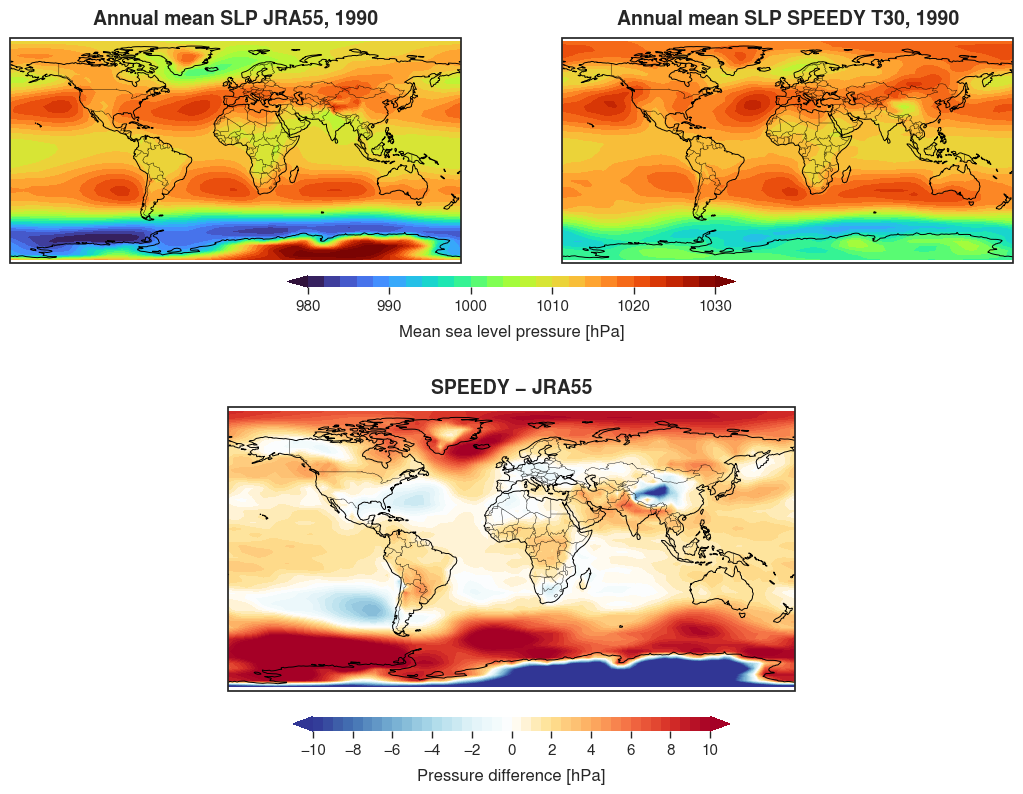

In [10]:
sns.set_theme(style="white")
plt.rcParams.update({"font.family": "Nimbus Sans"})

# Pa -> hPa for plotting
MSLP_JRA_plot = MSLP_JRA_mean / 100.
MSLP_SPEEDY_plot = MSLP_SPEEDY_mean / 100.
MSLP_diff_plot = MSLP_diff / 100.

pressure_cmap = plt.get_cmap("turbo")

diff_cmap = LinearSegmentedColormap.from_list(
    "PressureBlueWhiteRed",
    ["#313695","#4575b4","#74add1","#abd9e9","#e0f3f8","#ffffff",
     "#fee090","#fdae61","#f46d43","#d73027","#a50026"], N=256
)

pressure_levels = np.arange(980, 1032, 2)
pressure_ticks = np.arange(980, 1031, 10)

diff_levels = np.arange(-10, 10.5, 0.5)
diff_norm = mcolors.TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
diff_ticks = np.arange(-10, 11, 2)

def make_cyclic(da):
    data, lon = add_cyclic_point(da.values, coord=da.lon.values, axis=da.get_axis_num("lon"))
    return data, lon

def setup_map(ax):
    ax.set_global()
    ax.coastlines(resolution="110m", linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)

fig = plt.figure(figsize=(14, 9), facecolor="white")
gs = fig.add_gridspec(2, 6, height_ratios=[1, 1.3], hspace=0.42, wspace=0.12)

ax1 = fig.add_subplot(gs[0, 0:3], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[0, 3:6], projection=ccrs.PlateCarree())
ax3 = fig.add_subplot(gs[1, 0:6], projection=ccrs.PlateCarree())

# JRA55
data, lon = make_cyclic(MSLP_JRA_plot)
im1 = ax1.contourf(
    lon, MSLP_JRA_plot.lat, data, levels=pressure_levels,
    cmap=pressure_cmap, transform=ccrs.PlateCarree(), extend="both"
)
setup_map(ax1)
ax1.set_title("Annual mean SLP JRA55, 1990",
              fontsize=14, fontweight="bold", pad=10)

# SPEEDY
data, lon = make_cyclic(MSLP_SPEEDY_plot)
im2 = ax2.contourf(
    lon, MSLP_SPEEDY_plot.lat, data, levels=pressure_levels,
    cmap=pressure_cmap, transform=ccrs.PlateCarree(), extend="both"
)
setup_map(ax2)
ax2.set_title("Annual mean SLP SPEEDY T30, 1990",
              fontsize=14, fontweight="bold", pad=10)

# Difference
data, lon = make_cyclic(MSLP_diff_plot)
im3 = ax3.contourf(
    lon, MSLP_diff_plot.lat, data, levels=diff_levels,
    norm=diff_norm, cmap=diff_cmap,
    transform=ccrs.PlateCarree(), extend="both"
)
setup_map(ax3)
ax3.set_title("SPEEDY − JRA55", fontsize=14, fontweight="bold", pad=10)

# Colorbars
cbar1 = fig.colorbar(
    im1, ax=[ax1, ax2], orientation="horizontal",
    fraction=0.045, pad=0.05, aspect=40, ticks=pressure_ticks
)
cbar1.set_label("Mean sea level pressure [hPa]", fontsize=12, labelpad=8)
cbar1.ax.tick_params(labelsize=11, length=5, width=1)
cbar1.outline.set_visible(False)

cbar2 = fig.colorbar(
    im3, ax=ax3, orientation="horizontal",
    fraction=0.045, pad=0.08, aspect=30, ticks=diff_ticks
)
cbar2.set_label("Pressure difference [hPa]", fontsize=12, labelpad=8)
cbar2.ax.tick_params(labelsize=11, length=5, width=1)
cbar2.outline.set_visible(False)

fig.savefig("../figures/diff_annual_mean_mslp_1990.png", dpi=150, bbox_inches="tight")
plt.show()